In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Literal
import matplotlib.patches as mpatches
import seaborn as sns

In [2]:
# Set plotting style
plt.rcParams.update({
    "grid.linewidth":   0.5,
    "font.size":        10,
    "axes.titlesize":   11,
    "axes.titleweight": "bold",
})

BLUE   = "#378ADD"
TEAL   = "#1D9E75"
AMBER  = "#EF9F27"
CORAL  = "#D85A30"
PURPLE = "#7F77DD"
GRAY   = "#888780"
PALETTE = [BLUE, TEAL, AMBER, CORAL, PURPLE, GRAY,
           "#639922","#BA7517","#185FA5","#3B6D11"]

In [11]:
#file_path = r""
df = pd.read_csv("dataset_mood_smartphone.csv")

In [12]:
# Add date and hour only columns 
df["time"] = pd.to_datetime(df["time"])
df["date"] = df["time"].dt.date
df["date"] = pd.to_datetime(df["date"])
df["hour"] = df["time"].dt.hour
df["day_of_week"] = df["time"].dt.day_name()
df["month"] = df["time"].dt.month_name()
df["weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"])
df.head()

,Unnamed: 0,id,time,variable,value,date,hour,day_of_week,month,weekend
0,1,AS14.01,2014-02-26 13:00:00,mood,6.0,2014-02-26,13,Wednesday,February,False
1,2,AS14.01,2014-02-26 15:00:00,mood,6.0,2014-02-26,15,Wednesday,February,False
2,3,AS14.01,2014-02-26 18:00:00,mood,6.0,2014-02-26,18,Wednesday,February,False
3,4,AS14.01,2014-02-26 21:00:00,mood,7.0,2014-02-26,21,Wednesday,February,False
4,5,AS14.01,2014-02-27 09:00:00,mood,6.0,2014-02-27,9,Thursday,February,False


## Exploratory Data Analysis

In [5]:
print("Number of observations x Number of columns:", df.shape)
print("Earliest timestamp:", df['time'].min())
print("Latest timestamp", df['time'].max())
print("Unique users:", df['id'].nunique())
print("Unique variables:", df['variable'].nunique())
print("Total missing values (in value column):", df['value'].isnull().sum())

Number of observations x Number of columns: (376912, 10)
Earliest timestamp: 2014-02-17 07:00:52.197000
Latest timestamp 2014-06-09 00:00:00
Unique users: 27
Unique variables: 19
Total missing values (in value column): 202


In [6]:
grouped = df.groupby("variable")["value"]
# Total count and missing count per variable
total_per_variable = grouped.count()
missing_per_variable = grouped.size() - grouped.count()
missing_pct = (missing_per_variable / (missing_per_variable + total_per_variable)) * 100

stats = grouped.describe().rename(columns={"50%": "median"})
stats["missing"] = missing_per_variable
stats["missing %"] = missing_pct.round(1).fillna(100.0)
stats

,count,mean,std,min,25%,median,75%,max,missing,missing %
variable,,,,,,,,,,
activity,22965.0,0.115958,0.186946,0.000,0.00000,0.021739,0.158333,1.000,0,0.0
appCat.builtin,91288.0,18.538262,415.989243,-82798.871,2.02000,4.038000,9.922000,33960.246,0,0.0
appCat.communication,74276.0,43.343792,128.912750,0.006,5.21800,16.225500,45.475750,9830.777,0,0.0
appCat.entertainment,27125.0,37.576480,262.960476,-0.011,1.33400,3.391000,14.922000,32148.677,0,0.0
appCat.finance,939.0,21.755251,39.218361,0.131,4.07200,8.026000,20.155000,355.513,0,0.0
appCat.game,813.0,128.391615,327.145246,1.003,14.14800,43.168000,123.625000,5491.793,0,0.0
appCat.office,5642.0,22.578892,449.601382,0.003,2.00400,3.106000,8.043750,32708.818,0,0.0
appCat.other,7650.0,25.810839,112.781355,0.014,7.01900,10.028000,16.829250,3892.038,0,0.0
appCat.social,19145.0,72.401906,261.551846,0.094,9.03000,28.466000,75.372000,30000.906,0,0.0


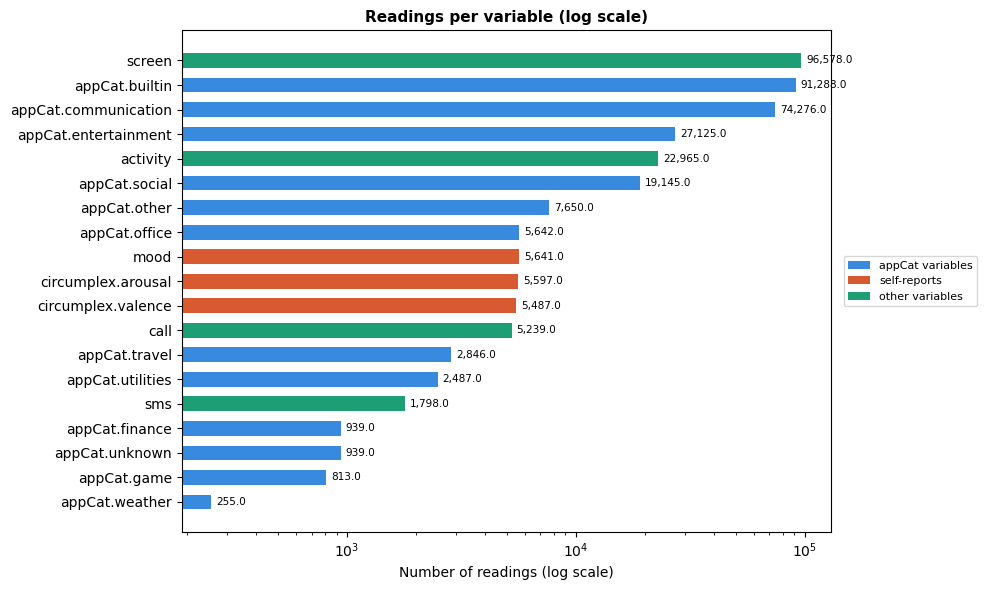

In [7]:
counts = stats["count"].sort_values(ascending=True)
colors_bar = [
    BLUE if "appCat" in v else
    CORAL if v in ("mood", "circumplex.arousal", "circumplex.valence") else
    TEAL
    for v in counts.index
]

plt.figure(figsize=(10, 6))
plt.barh(counts.index, counts.values, height=0.6, color=colors_bar)
plt.xscale("log")
plt.xlabel("Number of readings (log scale)")
plt.title("Readings per variable (log scale)")
plt.legend(
    handles=[
        mpatches.Patch(facecolor=BLUE, label="appCat variables"),
        mpatches.Patch(facecolor=CORAL, label="self-reports"),
        mpatches.Patch(facecolor=TEAL, label="other variables"),
    ],
    fontsize=8,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    frameon=True,
)
for value, variable in zip(counts.values, counts.index):
    plt.text(value * 1.05, variable, f"{value:,}", va="center", fontsize=7.5)
plt.tight_layout()
plt.show()

# Sensor data (screen, appCat) is sampled far more than self-reports (mood, arousal). Maybe table is enough to show this
# Need to understand how to handle this when we will pivot the data to wide format and have missing values for self-reports.

In [13]:
# Check and remove negative values for appCat.builtin (before aggregating to pivot)
is_builtin = df["variable"].eq("appCat.builtin")
is_negative_builtin = is_builtin & (df["value"] < 0)

print("Negative appCat.builtin rows:", int(is_negative_builtin.sum()))
df = df.loc[~is_negative_builtin].copy()
print("Remaining negative appCat.builtin rows:", int(((df["variable"] == "appCat.builtin") & (df["value"] < 0)).sum()))

Negative appCat.builtin rows: 3
Remaining negative appCat.builtin rows: 0


In [14]:
# Check and remove negative values for appCat.entertainment
is_entr = df["variable"].eq("appCat.entertainment")
is_negative_entr = is_entr & (df["value"] < 0)

print("Negative appCat.entertainment rows:", int(is_negative_entr.sum()))
df = df.loc[~is_negative_entr].copy()
print("Remaining negative appCat.entertainment rows:", int(((df["variable"] == "appCat.entertainment") & (df["value"] < 0)).sum()))

Negative appCat.entertainment rows: 1
Remaining negative appCat.entertainment rows: 0


In [15]:
# WAIT FOR NAS!
print("Number of NAs before dropping:", df['value'].isnull().sum())
#df.dropna(subset=["value"], inplace=True)
print("Number of NAs after dropping:", df['value'].isnull().sum())

Number of NAs before dropping: 202
Number of NAs after dropping: 202


In [16]:
# Creating wide format dataset
mood_data = (df[df["variable"].isin(["mood", "circumplex.arousal", "circumplex.valence", "activity"])]).sort_values(by=["id", "time"])
mood_pivot = mood_data.pivot_table(
    index=["id", "date"], 
    columns="variable", 
    values="value", 
    aggfunc=["mean", "max", "min", "std", "first", "last", "count"]
)
mood_pivot.columns = [f"{var}_{stat}" for stat, var in mood_pivot.columns]
mood_pivot = mood_pivot.reset_index()

mood_pivot.head()

,id,date,activity_mean,circumplex.arousal_mean,circumplex.valence_mean,mood_mean,activity_max,circumplex.arousal_max,circumplex.valence_max,mood_max,...,circumplex.valence_first,mood_first,activity_last,circumplex.arousal_last,circumplex.valence_last,mood_last,activity_count,circumplex.arousal_count,circumplex.valence_count,mood_count
0,AS14.01,2014-02-26,NaN,-0.25,0.750000,6.250000,NaN,1.0,1.0,7.0,...,0.0,6.0,NaN,1.0,1.0,7.0,NaN,4.0,4.0,4.0
1,AS14.01,2014-02-27,NaN,0.00,0.333333,6.333333,NaN,1.0,1.0,7.0,...,0.0,6.0,NaN,1.0,1.0,7.0,NaN,3.0,3.0,3.0
2,AS14.01,2014-03-20,0.081548,NaN,NaN,NaN,0.091667,NaN,NaN,NaN,...,NaN,NaN,0.091667,NaN,NaN,NaN,2.0,NaN,NaN,NaN
3,AS14.01,2014-03-21,0.134050,0.20,0.200000,6.200000,0.798387,1.0,1.0,7.0,...,0.0,6.0,0.000000,1.0,0.0,6.0,23.0,5.0,5.0,5.0
4,AS14.01,2014-03-22,0.236880,0.60,0.500000,6.400000,0.508475,1.0,1.0,7.0,...,1.0,7.0,0.000000,1.0,-1.0,5.0,16.0,5.0,4.0,5.0


In [17]:
rec_vars = ['screen',
 'call',
 'sms',
 'appCat.builtin',
 'appCat.communication',
 'appCat.entertainment',
 'appCat.finance',
 'appCat.game',
 'appCat.office',
 'appCat.other',
 'appCat.social',
 'appCat.travel',
 'appCat.unknown',
 'appCat.utilities',
 'appCat.weather']

rec_data = (df[df["variable"].isin(rec_vars)]).sort_values(by=["id", "time"])
rec_pivot = rec_data.pivot_table(
    index=["id", "date"], 
    columns=["variable"], 
    values="value", 
    aggfunc=["sum"]
)
rec_pivot.columns = [f"{var}_{stat}" for stat, var in rec_pivot.columns]
rec_pivot = rec_pivot.reset_index()

rec_pivot.head()

,id,date,appCat.builtin_sum,appCat.communication_sum,appCat.entertainment_sum,appCat.finance_sum,appCat.game_sum,appCat.office_sum,appCat.other_sum,appCat.social_sum,appCat.travel_sum,appCat.unknown_sum,appCat.utilities_sum,appCat.weather_sum,call_sum,screen_sum,sms_sum
0,AS14.01,2014-02-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
1,AS14.01,2014-02-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
2,AS14.01,2014-02-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,2.0
3,AS14.01,2014-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,3.0
4,AS14.01,2014-02-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [18]:
df_wide = mood_pivot.merge(rec_pivot, on=["id", "date"], how="outer")
df_wide["day_of_week"] = df_wide["date"].dt.day_name()
df_wide["month"] = df_wide["date"].dt.month_name()
df_wide["weekend"] = df_wide["day_of_week"].isin(["Saturday", "Sunday"])
print("Wide format shape:", df_wide.shape)
df_wide.head()

Wide format shape: (1973, 48)


,id,date,activity_mean,circumplex.arousal_mean,circumplex.valence_mean,mood_mean,activity_max,circumplex.arousal_max,circumplex.valence_max,mood_max,...,appCat.travel_sum,appCat.unknown_sum,appCat.utilities_sum,appCat.weather_sum,call_sum,screen_sum,sms_sum,day_of_week,month,weekend
0,AS14.01,2014-02-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.0,NaN,NaN,Monday,February,False
1,AS14.01,2014-02-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,Tuesday,February,False
2,AS14.01,2014-02-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.0,NaN,2.0,Wednesday,February,False
3,AS14.01,2014-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.0,NaN,3.0,Thursday,February,False
4,AS14.01,2014-02-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,Friday,February,False


In [ ]:
# create a row per each day 
df_daily = (df_wide.set_index('date')
           .groupby('id')
           .resample('D').asfreq()
           .drop(columns=['id'])
           .reset_index()).copy()

In [21]:
df_daily.head(10)

,id,date,activity_mean,circumplex.arousal_mean,circumplex.valence_mean,mood_mean,activity_max,circumplex.arousal_max,circumplex.valence_max,mood_max,...,appCat.travel_sum,appCat.unknown_sum,appCat.utilities_sum,appCat.weather_sum,call_sum,screen_sum,sms_sum,day_of_week,month,weekend
0,AS14.01,2014-02-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.0,NaN,NaN,Monday,February,False
1,AS14.01,2014-02-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,Tuesday,February,False
2,AS14.01,2014-02-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.0,NaN,2.0,Wednesday,February,False
3,AS14.01,2014-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.0,NaN,3.0,Thursday,February,False
4,AS14.01,2014-02-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,Friday,February,False
5,AS14.01,2014-02-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.0,NaN,1.0,Saturday,February,True
6,AS14.01,2014-02-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,AS14.01,2014-02-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,AS14.01,2014-02-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.0,NaN,NaN,Tuesday,February,False
9,AS14.01,2014-02-26,NaN,-0.25,0.75,6.25,NaN,1.0,1.0,7.0,...,NaN,NaN,NaN,NaN,1.0,NaN,2.0,Wednesday,February,False


In [24]:
df_daily.isna().sum()

id                             0
date                           0
activity_mean                966
circumplex.arousal_mean      886
circumplex.valence_mean      888
mood_mean                    886
activity_max                 966
circumplex.arousal_max       886
circumplex.valence_max       888
mood_max                     886
activity_min                 966
circumplex.arousal_min       886
circumplex.valence_min       888
mood_min                     886
activity_std                 976
circumplex.arousal_std       911
circumplex.valence_std       916
mood_std                     911
activity_first               966
circumplex.arousal_first     886
circumplex.valence_first     888
mood_first                   886
activity_last                966
circumplex.arousal_last      886
circumplex.valence_last      888
mood_last                    886
activity_count               966
circumplex.arousal_count     886
circumplex.valence_count     886
mood_count                   886
appCat.bui

In [ ]:
# there are missing consecutive days: issue for inputting 
mood_wide = (
    df_daily.loc[df_daily["mood_mean"].notna(), ["id", "date", "mood_mean"]]
    .drop_duplicates(subset=["id", "date"])
    .sort_values(["id", "date"])
)

# For each user, compute the number of days between mood observations minus the observed days themselves.
gaps = mood_wide.groupby("id")["date"].diff().dt.days.sub(1)
gaps.value_counts().sort_index()

date
0.0     1216
1.0       19
2.0        3
6.0        1
11.0       1
21.0       1
Name: count, dtype: int64

In [25]:
# fill zero for appCat vars
zero_vars = ['appCat.builtin_sum', 'appCat.communication_sum', 'appCat.entertainment_sum',
             'appCat.finance_sum', 'appCat.game_sum', 'appCat.office_sum',
             'appCat.other_sum', 'appCat.social_sum', 'appCat.travel_sum',
             'appCat.unknown_sum', 'appCat.utilities_sum', 'appCat.weather_sum',
             'call_sum', 'screen_sum', 'sms_sum']

for col in zero_vars:
    if col in df_daily.columns:
        df_daily[col] = df_daily[col].fillna(0) 

In [26]:
df_daily[zero_vars].isna().sum()

appCat.builtin_sum          0
appCat.communication_sum    0
appCat.entertainment_sum    0
appCat.finance_sum          0
appCat.game_sum             0
appCat.office_sum           0
appCat.other_sum            0
appCat.social_sum           0
appCat.travel_sum           0
appCat.unknown_sum          0
appCat.utilities_sum        0
appCat.weather_sum          0
call_sum                    0
screen_sum                  0
sms_sum                     0
dtype: int64

In [27]:
# fill for mood and circumplex vars using different methods (LOCF, rolling mean)
target_vars = ["mood_mean", "circumplex.arousal_mean", "circumplex.valence_mean"]
# method 1: forward fill
df_LOCF = df_daily.copy()
for var in target_vars:
   # limit: 2 days
    df_LOCF[var] = df_LOCF.groupby("id")[var].ffill(limit=2)

In [28]:
# method 2: rolling mean
df_rolling = df_daily.copy()
for var in target_vars:
    # rolling mean with window of 3 days 
    rolling_mean = df_daily.groupby("id")[var].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
    df_rolling[var] = df_rolling[var].fillna(rolling_mean)

In [29]:
df_LOCF[target_vars].isna().sum()

mood_mean                  846
circumplex.arousal_mean    846
circumplex.valence_mean    846
dtype: int64

In [30]:
df_rolling[target_vars].isna().sum()

mood_mean                  846
circumplex.arousal_mean    846
circumplex.valence_mean    846
dtype: int64

In [ ]:
# Clean NAs in mood_mean (self-reports), if gap is larger than 2 days
print("Number of NAs in mood_mean before dropping:", df_wide["mood_mean"].isnull().sum())
df_wide.dropna(subset=["mood_mean", "circumplex.valence_mean", "mood_std", "circumplex.valence_std"], inplace=True)
print("Number of NAs in mood_mean after dropping:", df_wide["mood_mean"].isnull().sum())

Number of NAs in mood_mean before dropping: 0
Number of NAs in mood_mean after dropping: 0


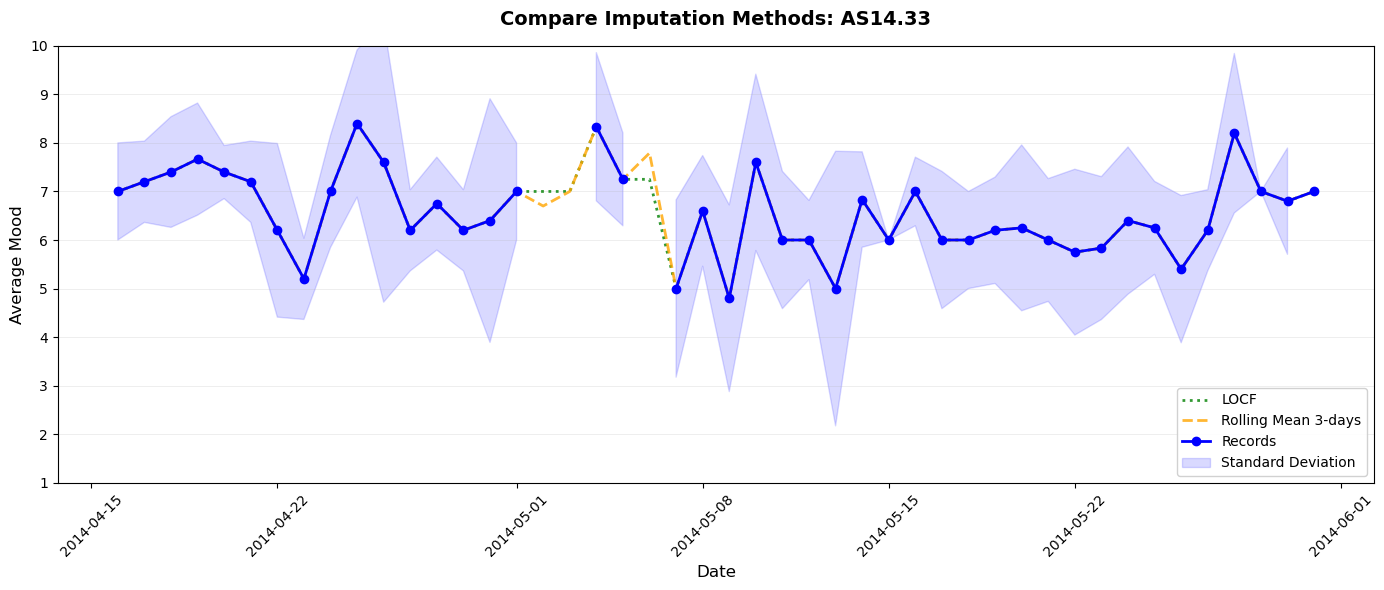

In [48]:
# Plots
# Plot 1: Time series of mood_mean + std users (before and after imputation)
user_sel = "AS14.33" 

df_orig = df_wide[df_wide["id"] == user_sel]
df_locf = df_LOCF[df_LOCF["id"] == user_sel]
df_roll = df_rolling[df_rolling["id"] == user_sel]


plt.figure(figsize=(14, 6))
plt.plot(df_locf["date"], df_locf["mood_mean"], 
         label="LOCF", color="green", linestyle=":", linewidth=2, alpha=0.8)

plt.plot(df_roll["date"], df_roll["mood_mean"], 
         label="Rolling Mean 3-days", color="orange", linestyle="--", linewidth=2, alpha=0.8)

plt.plot(df_orig["date"], df_orig["mood_mean"], 
         label="Records", color="blue", marker="o", markersize=6, linewidth=2)

plt.fill_between(df_orig["date"], 
                 df_orig["mood_mean"] - df_orig["mood_std"], 
                 df_orig["mood_mean"] + df_orig["mood_std"], 
                 color="blue", alpha=0.15, label="Standard Deviation")

plt.title(f"Compare Imputation Methods: {user_sel}", fontsize=14, pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Mood", fontsize=12)
plt.ylim(1, 10) 
plt.legend(loc="lower right", framealpha=0.9)
plt.grid(True, axis='y', alpha=0.3) 
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

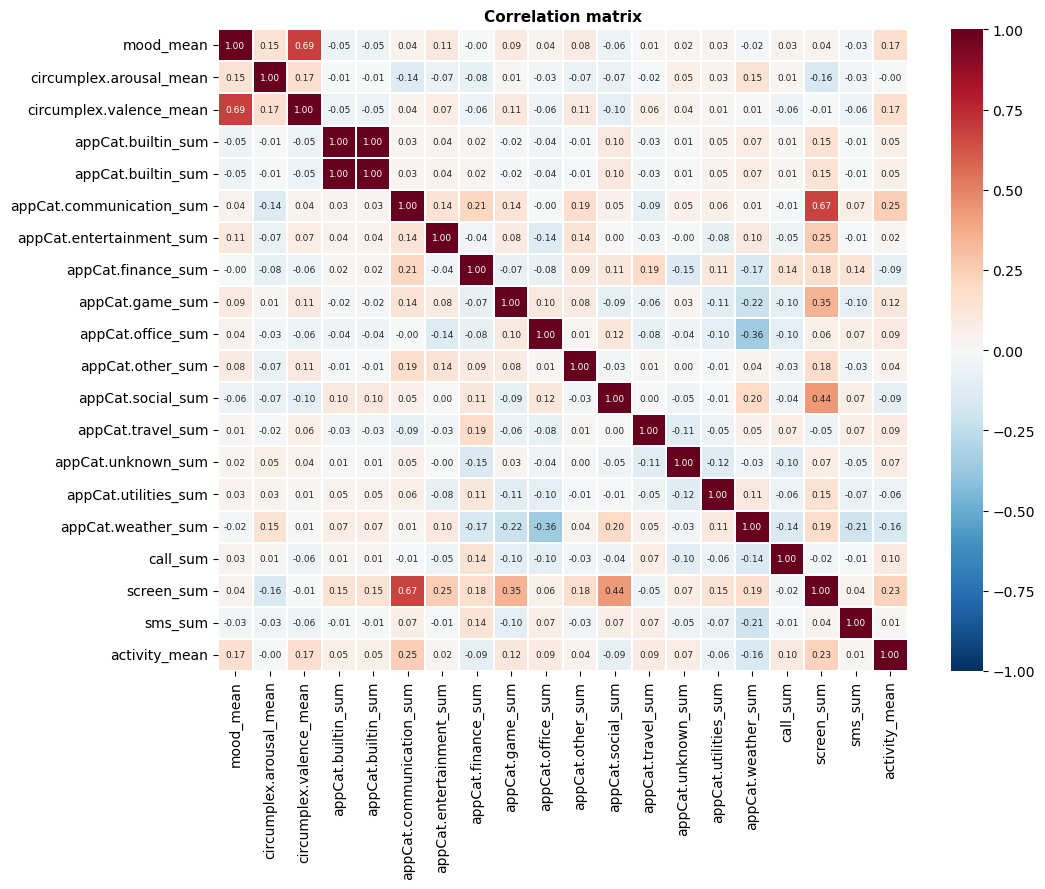

In [56]:
cols_to_correlate = ["mood_mean", "circumplex.arousal_mean", "circumplex.valence_mean", 
                     'appCat.builtin_sum','appCat.builtin_sum',
       'appCat.communication_sum', 'appCat.entertainment_sum',
       'appCat.finance_sum', 'appCat.game_sum', 'appCat.office_sum',
       'appCat.other_sum', 'appCat.social_sum', 'appCat.travel_sum',
       'appCat.unknown_sum', 'appCat.utilities_sum', 'appCat.weather_sum',
       'call_sum', 'screen_sum', 'sms_sum', "activity_mean"]
corr_matrix = df_wide[cols_to_correlate].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    annot_kws={"size": 6.5},
    ax=ax,
)
ax.set_title("Correlation matrix", fontweight="bold")
plt.tight_layout()
plt.show()

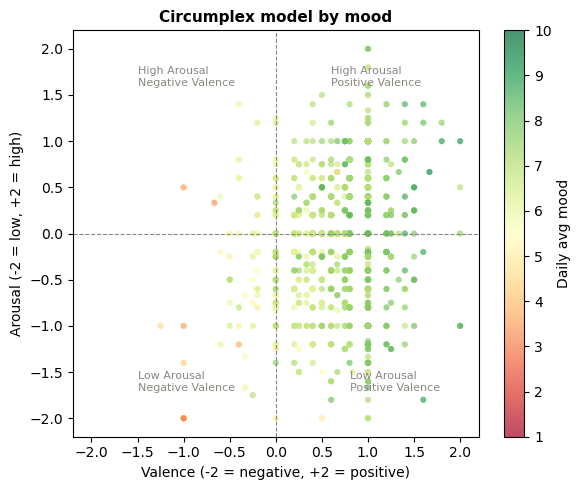

In [40]:
# Check valence and arousal correlation with mood 
circ = (df[df["variable"].isin(["circumplex.arousal","circumplex.valence","mood"])]
        .groupby(["id","date","variable"])["value"].mean()
        .unstack("variable").reset_index().dropna())
 
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(circ["circumplex.valence"], circ["circumplex.arousal"],
                c=circ["mood"], cmap="RdYlGn", vmin=1, vmax=10,
                alpha=0.7, linewidths=0, s = 20)
plt.colorbar(sc, ax=ax, label="Daily avg mood")
plt.axhline(0, color=GRAY, lw=0.8, ls="--")
plt.axvline(0, color=GRAY, lw=0.8, ls="--")
plt.ylim(-2.2, 2.2)
plt.xlim(-2.2, 2.2)
plt.xlabel("Valence (-2 = negative, +2 = positive)")
plt.ylabel("Arousal (-2 = low, +2 = high)")
plt.title("Circumplex model by mood")
# Quadrant labels
for x, y, lbl in [(.6, 1.6, "High Arousal\nPositive Valence"), (.8, -1.7, "Low Arousal\nPositive Valence"),
                   (-1.5, 1.6, "High Arousal\nNegative Valence"), (-1.5, -1.7, "Low Arousal\nNegative Valence")]:
    plt.text(x, y, lbl, fontsize=8, color=GRAY)
plt.tight_layout()
plt.show()

In [ ]:
## OLD VERSION

In [ ]:
# Distribution of all variables (histograms)
variables = df["variable"].unique()
fig, axes = plt.subplots(4, 5, figsize=(18, 12))
 
for ax, var in zip(axes.flatten(), variables):
    values = df[df["variable"] == var]["value"].dropna()
    ax.hist(values, bins=30, color="steelblue", edgecolor="white")
    ax.set_title(var, fontsize=8)
    ax.set_xlabel("value", fontsize=7)
    ax.set_ylabel("count", fontsize=7)
 
# hide the last empty subplot
axes.flatten()[-1].set_visible(False)
 
plt.suptitle("Distribution of all variables", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
# Focus on mood variables
mood_vars = ["mood", "circumplex.arousal", "circumplex.valence"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4)) 
for ax, var in zip(axes, mood_vars):
    values = df[df["variable"] == var]["value"].dropna()
    if var == "mood":
        bins = np.arange(1, 11) - 0.5
        ax.hist(values, bins=10, color="coral", edgecolor="white")
    else:
        bins = np.arange(-2, 3) - 0.5
        ax.hist(values, bins=5, color="coral", edgecolor="white")
    ax.set_title(var, fontsize=10)
    ax.set_xlabel("value", fontsize=9)
    ax.set_ylabel("count", fontsize=9)

In [ ]:
# Focus on screen and app category variables
# highly skewed distributions with many zeros, so we can log-transform the values
duration_vars = ["screen", "appCat.builtin", "appCat.communication",
                 "appCat.entertainment", "appCat.finance", "appCat.game",
                 "appCat.office", "appCat.other", "appCat.social",
                 "appCat.travel", "appCat.unknown", "appCat.utilities",
                 "appCat.weather"]
fig, axes = plt.subplots(4, 4, figsize=(18, 12))
 
for ax, var in zip(axes.flatten(), duration_vars):
    if var in duration_vars:
        values = df[df["variable"] == var]["value"].dropna()
        values = np.log1p(values.clip(lower=0)) # to avoid log of negative values + log(0) issues
        ax.set_xlabel("log(1 + seconds)", fontsize=7)
        ax.hist(values, bins=30, color="steelblue", edgecolor="white")
        ax.set_title(var, fontsize=8)
        ax.set_ylabel("count", fontsize=7)

axes.flatten()[-1].set_visible(False)
axes.flatten()[-2].set_visible(False)
axes.flatten()[-3].set_visible(False)
 
plt.suptitle("Distribution of Screen variables", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# correlation matrix for numeric variables in long-format data (**Check**)
correlation_data = (
    df.groupby(["id", "date", "variable"])["value"]
      .mean() 
      .unstack("variable")
)

correlation_data = correlation_data.dropna(axis=1, how="all")
correlation_matrix = correlation_data.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    annot_kws={"size": 6.5},
    ax=ax,
)
ax.set_title("Correlation matrix", fontweight="bold")
plt.tight_layout()
plt.show()

# high correlation between mood and valance

In [ ]:
# Check valence and arousal correlation with mood 
circ = (df[df["variable"].isin(["circumplex.arousal","circumplex.valence","mood"])]
        .groupby(["id","date","variable"])["value"].mean()
        .unstack("variable").reset_index().dropna())
 
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(circ["circumplex.valence"], circ["circumplex.arousal"],
                c=circ["mood"], cmap="RdYlGn", vmin=1, vmax=10,
                alpha=0.7, linewidths=0, s = 20)
plt.colorbar(sc, ax=ax, label="Daily avg mood")
plt.axhline(0, color=GRAY, lw=0.8, ls="--")
plt.axvline(0, color=GRAY, lw=0.8, ls="--")
plt.ylim(-2.2, 2.2)
plt.xlim(-2.2, 2.2)
plt.xlabel("Valence (-2 = negative, +2 = positive)")
plt.ylabel("Arousal (-2 = low, +2 = high)")
plt.title("Circumplex model by mood")
# Quadrant labels
for x, y, lbl in [(.6, 1.6, "High Arousal\nPositive Valence"), (.8, -1.7, "Low Arousal\nPositive Valence"),
                   (-1.5, 1.6, "High Arousal\nNegative Valence"), (-1.5, -1.7, "Low Arousal\nNegative Valence")]:
    plt.text(x, y, lbl, fontsize=8, color=GRAY)
plt.tight_layout()
plt.show()

In [ ]:
## Other plots for exploration (e.g., usage patterns by hour of day, mood over time, etc.)
# Distribution of mood ratings per user
mood = df[df["variable"] == "mood"][["id", "time", "value"]].copy()
# daily averages per user
daily_mood = mood.groupby(["id", "time"])["value"].mean().reset_index()
user_order = (daily_mood.groupby("id")["value"]
              .median().sort_values().index.tolist())
data_per_user = [daily_mood[daily_mood["id"] == u]["value"].values
                 for u in user_order]
bp = plt.boxplot(data_per_user, vert=True, patch_artist=True, medianprops=dict(color="white", lw=0.3))
for patch in bp["boxes"]:
    patch.set_facecolor(BLUE)
    patch.set_alpha(0.75)
ax = plt.gca()
ax.set_xticks(range(1, len(user_order) + 1))
ax.set_xticklabels([u.replace("AS14.", "") for u in user_order], rotation=45, ha="right", fontsize=8)
plt.xlabel("User ID (suffix only)")
plt.ylabel("Daily average mood")
plt.title("Daily avg mood per user")
plt.tight_layout()
plt.show()


In [ ]:
# Check mood patterns by weekday, month, and hour of day (line plots)
all_users = sorted(df.loc[df["variable"] == "mood", "id"].dropna().unique())
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
month_order = sorted(df.loc[df["variable"] == "mood", "time"].dt.month.dropna().unique())
month_labels = [pd.Timestamp(month=month, day=1, year=2000).strftime("%b") for month in month_order]
hour_order = list(range(6, 30))
user_colors = dict(zip(all_users, plt.cm.tab20(np.linspace(0, 1, max(len(all_users), 1)))))
 
fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
 
for uid in all_users:
    user_mood = df[(df["id"] == uid) & (df["variable"] == "mood")].copy()
    user_mood["weekday"] = user_mood["time"].dt.day_name()
    user_mood["month"] = user_mood["time"].dt.month
    user_mood["hour"] = user_mood["time"].dt.hour
 
    weekday_mood = user_mood.groupby("weekday")["value"].mean().reindex(weekday_order)
    month_mood = user_mood.groupby("month")["value"].mean().reindex(month_order)
    hour_mood = user_mood.groupby("hour")["value"].mean().reindex(range(24))
    hour_mood = pd.concat([hour_mood.loc[6:23], hour_mood.loc[0:5]])
 
    axes[0].plot(month_order, month_mood.values, "-o", color=user_colors[uid], lw=1.1, alpha=0.7)
    axes[1].plot(hour_order, hour_mood.values, "-o", color=user_colors[uid], lw=1.1, alpha=0.7)
    axes[2].plot(weekday_order, weekday_mood.values, "-o", color=user_colors[uid], lw=1.1, alpha=0.7)
 
axes[0].set_title("Mood by month")
axes[1].set_title("Mood by hour of day")
axes[2].set_title("Mood by weekday")
 
axes[0].set_ylabel("Mood")
axes[0].set_ylim(3.7, 10)
axes[1].set_ylim(3.7, 10)
axes[2].set_ylim(3.7, 10)
 

axes[0].set_xticks(month_order)
axes[0].set_xticklabels(month_labels, rotation=30)
axes[1].set_xticks([6, 9, 12, 15, 18, 21, 24, 27, 30])
axes[1].set_xticklabels(["6am", "9am", "12pm", "3pm", "6pm", "9pm", "12am", "3am", "6am"])
axes[1].axvspan(20, 30, color=GRAY, alpha=0.12)
axes[1].set_xlim(6, 30)
axes[2].tick_params(axis="x", rotation=30)

axes[0].set_xlabel("Month")
axes[1].set_xlabel("Hour of day")
axes[2].set_xlabel("Weekday")
 
fig.suptitle("Mood by weekday, month, and time of day", fontweight="bold")
plt.show()

In [ ]:
import math
import matplotlib.dates as mdates

mood_data = df[df["variable"] == "mood"].copy()
all_users = sorted(mood_data["id"].dropna().unique())

n_users = len(all_users)
n_cols = 2 if n_users > 1 else 1
n_rows = math.ceil(n_users / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.2 * n_rows), sharex=False)
axes = np.atleast_1d(axes).reshape(n_rows, n_cols)

for idx, uid in enumerate(all_users):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row, col]

    user_mood = mood_data[mood_data["id"] == uid].copy()
    daily_mood = (
        user_mood.groupby("date")["value"]
        .agg(mood_count="count", mood_mean="mean", mood_std="std")
    )

    full_dates = pd.date_range(daily_mood.index.min(), daily_mood.index.max(), freq="D")
    daily_mood = daily_mood.reindex(full_dates)
    daily_mood.index.name = "date"
    missing_days = daily_mood["mood_count"].isna() | daily_mood["mood_count"].eq(0)

    ax.bar(
        daily_mood.index,
        daily_mood["mood_count"].fillna(0),
        color=TEAL,
        alpha=0.75,
        width=0.9,
    )
    ax.set_title(f"User {uid}", fontsize=10)
    ax.set_ylabel("Mood entries")
    ax.set_ylim(bottom=0)

    twin_ax = ax.twinx()
    twin_ax.plot(
        daily_mood.index,
        daily_mood["mood_mean"],
        color=CORAL,
        marker="o",
        linewidth=1.5,
        markersize=3,
    )
    twin_ax.fill_between(
        daily_mood.index,
        daily_mood["mood_mean"] - daily_mood["mood_std"],
        daily_mood["mood_mean"] + daily_mood["mood_std"],
        color=CORAL,
        alpha=0.18,
    )
    twin_ax.set_ylabel("Mood")
    twin_ax.set_ylim(0.5, 10.5)

    for day in daily_mood.index[missing_days]:
        ax.axvspan(day - pd.Timedelta(days=0.5), day + pd.Timedelta(days=0.5), color=GRAY, alpha=0.08)

    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

for idx in range(n_users, n_rows * n_cols):
    row = idx // n_cols
    col = idx % n_cols
    axes[row, col].set_visible(False)

fig.suptitle("Daily mood recordings for all users", fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

summary = (
    mood_data.groupby("id")
    .agg(first_date=("date", "min"), last_date=("date", "max"), mood_entries=("value", "count"))
    .sort_index()
)
summary["missing_days"] = (
    summary["last_date"] - summary["first_date"]
).dt.days + 1 - summary["mood_entries"]
summary

In [ ]:
import math
import matplotlib.dates as mdates

arousal_data = df[df["variable"] == "circumplex.valence"].copy()
all_users = sorted(arousal_data["id"].dropna().unique())

n_users = len(all_users)
n_cols = 2 if n_users > 1 else 1
n_rows = math.ceil(n_users / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.2 * n_rows), sharex=False)
axes = np.atleast_1d(axes).reshape(n_rows, n_cols)

for idx, uid in enumerate(all_users):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row, col]

    user_arousal = arousal_data[arousal_data["id"] == uid].copy()
    daily_arousal = (
        user_arousal.groupby("date")["value"]
        .agg(arousal_count="count", arousal_mean="mean", arousal_std="std")
    )

    full_dates = pd.date_range(daily_arousal.index.min(), daily_arousal.index.max(), freq="D")
    daily_arousal = daily_arousal.reindex(full_dates)
    daily_arousal.index.name = "date"
    missing_days = daily_arousal["arousal_count"].isna() | daily_arousal["arousal_count"].eq(0)

    ax.bar(
        daily_arousal.index,
        daily_arousal["arousal_count"].fillna(0),
        color=TEAL,
        alpha=0.75,
        width=0.9,
    )
    ax.set_title(f"User {uid}", fontsize=10)
    ax.set_ylabel("Mood entries")
    ax.set_ylim(bottom=0)

    twin_ax = ax.twinx()
    twin_ax.plot(
        daily_arousal.index,
        daily_arousal["arousal_mean"],
        color=CORAL,
        marker="o",
        linewidth=1.5,
        markersize=3,
    )
    twin_ax.fill_between(
        daily_arousal.index,
        daily_arousal["arousal_mean"] - daily_arousal["arousal_std"],
        daily_arousal["arousal_mean"] + daily_arousal["arousal_std"],
        color=CORAL,
        alpha=0.18,
    )
    twin_ax.set_ylabel("Mood")
    twin_ax.set_ylim(0.5, 10.5)

    for day in daily_arousal.index[missing_days]:
        ax.axvspan(day - pd.Timedelta(days=0.5), day + pd.Timedelta(days=0.5), color=GRAY, alpha=0.08)

    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

for idx in range(n_users, n_rows * n_cols):
    row = idx // n_cols
    col = idx % n_cols
    axes[row, col].set_visible(False)

fig.suptitle("Daily mood recordings for all users", fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

summary = (
    arousal_data.groupby("id")
    .agg(first_date=("date", "min"), last_date=("date", "max"), arousal_entries=("value", "count"))
    .sort_index()
)
summary["missing_days"] = (
    summary["last_date"] - summary["first_date"]
).dt.days + 1 - summary["arousal_entries"]
summary

In [ ]:
# Distribution of missing-day gaps between consecutive mood-recording dates
mood_days = (
    df.loc[df["variable"] == "mood", ["id", "date"]]
    .dropna()
    .drop_duplicates()
    .sort_values(["id", "date"])
)

# Difference in days between consecutive mood dates per user; subtract 1 to count missing days in-between.
gaps = mood_days.groupby("id")["date"].diff().dt.days.sub(1)
lacking_days = gaps[gaps > 0].astype(int)

lacking_distribution = lacking_days.value_counts().sort_index()

print("Distribution of lacking days between consecutive mood records:")
print(lacking_distribution)
print("\nTotal gap events:", int(lacking_days.shape[0]))
print("Total lacking days across all users:", int(lacking_days.sum()))

plt.figure(figsize=(8, 4))
plt.bar(lacking_distribution.index, lacking_distribution.values, color=AMBER, edgecolor="white")
plt.xlabel("Number of lacking days in a gap")
plt.ylabel("Frequency")
plt.title("Distribution of lacking days between mood recordings")
plt.xticks(lacking_distribution.index)
plt.tight_layout()
plt.show()

In [ ]:
usage_vars = ["screen", "appCat.office", "appCat.social",
                "appCat.communication", "appCat.entertainment"]
 
fig, axes = plt.subplots(len(usage_vars), 1, figsize=(10, 10), sharex=True)
 
for ax, var in zip(axes, usage_vars):
    hourly = (
        df[df["variable"] == var]
        .groupby(["date", "hour"])["value"]
        .mean()
        .groupby("hour")
        .mean()
        .reindex(range(24))
    )
    ax.plot(hourly.index, hourly.values, color="steelblue", lw=2)
    ax.fill_between(hourly.index, hourly.values, alpha=0.15, color="steelblue")
    ax.set_ylabel(var, fontsize=8)
    ax.set_xlim(0, 23)
    ax.set_xticks(range(0, 24, 2))
 
axes[-1].set_xlabel("Hour of day")
fig.suptitle("Average usage by hour of day", fontweight="bold")
plt.tight_layout()

In [ ]:
# Total daily usage per variable
daily_usage = (
    df[df["variable"].isin(usage_vars)]
    .groupby(["date", "variable"])["value"]
    .sum()
    .unstack("variable")
)

plt.figure(figsize=(11, 6))
for col in daily_usage.columns:
    plt.plot(daily_usage.index, daily_usage[col], linewidth=2, label=col)

plt.title("Total daily usage by variable", fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Total value per day")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## Notes

- data is between 02/2014 until 06/2014, but only for 2 people feb and june are included
- appCat.builtin and entertainment have min negative values: remove or clip?
- usage times have extreme outliers (e.g. screen max is approx 2.7 hours, social is 8h and office is 9h)
- call and sms mark events
- mood mean = 7.0, std = 1.0
- circumplex.valence mean = 0.69 (positive), arousal mean = -0.10 (calm)
 

Part 1B: Data Cleaning

In [ ]:
duration_vars = ["screen", "appCat.builtin", "appCat.communication",
                 "appCat.entertainment", "appCat.finance", "appCat.game",
                 "appCat.office", "appCat.other", "appCat.social",
                 "appCat.travel", "appCat.unknown", "appCat.utilities",
                 "appCat.weather"]

# check for negative values in duration variables (should not be possible)

negative_counts = df[df["variable"].isin(duration_vars) & (df["value"] < 0)].groupby("variable")["value"].count()
print(negative_counts)

In [ ]:
# cleaning the data

# replacing negative values with NaN for the two impossible negative minmums
duration_vars = ["screen", "appCat.builtin", "appCat.communication",
                 "appCat.entertainment", "appCat.finance", "appCat.game",
                 "appCat.office", "appCat.other", "appCat.social",
                 "appCat.travel", "appCat.unknown", "appCat.utilities",
                 "appCat.weather"]

for var in duration_vars:
    df.loc[(df["variable"] == var) & (df["value"] < 0), "value"] = np.nan

# making sure time in seconds is in 1 day range

outlier_counts = df[df["variable"].isin(duration_vars) & (df["value"] > 24*3600)].groupby("variable")["value"].count()
print(outlier_counts)

# no impossible values above 24 hours, so I am keeping the rest of the data as is. Now to pivot to wide format.


In [ ]:
# grouping mood, arousal, valence
mood_data = df[df["variable"].isin(["mood", "circumplex.arousal", "circumplex.valence"])]
mood_pivot = mood_data.pivot_table(index=["id", "date"], columns="variable", values="value", aggfunc="mean").reset_index()
mood_pivot.head()

In [ ]:
# grouping duration variables
duration_data = df[df["variable"].isin(duration_vars)]
duration_pivot = duration_data.pivot_table(index=["id", "date"], columns="variable", values="value", aggfunc="sum").reset_index()
duration_pivot.head()

In [ ]:
# grouping calls and sms variables
calls_sms_data = df[df["variable"].isin(["call", "sms"])]
calls_sms_pivot = calls_sms_data.pivot_table(index=["id", "date"], columns="variable", values="value", aggfunc="max").reset_index()
calls_sms_pivot.head()

In [ ]:
# combining pivot tables into one wide-format table

df_wide = mood_pivot.merge(duration_pivot, on=["id", "date"], how="outer").merge(calls_sms_pivot, on=["id", "date"], how="outer")
print("Wide format shape:", df_wide.shape)
df_wide.head()

There are a lot of not available data points. In areas like valence, mood and arousal I will assume that these are genuinely missed days and that these points will have to be imputed. On the other hand, there are multiple NaNs in collumns such as finance or weather apps. For now I will replace these NaNs with 0s, as my assumption is that people did not use these apps on certain days, and that their use would've been tracked automatically.

In [ ]:
# filling in apps usage NaNs with 0s, as assumption is that these were days when people did not use these apps, and that their use would've been tracked automatically. For mood, arousal and valence I will keep the NaNs for now, as I will impute them later.

for col in df_wide.columns:
    if col.startswith("appCat") or col == "screen" or col in ["call", "sms"]:
        df_wide[col] = df_wide[col].fillna(0)

df_wide.head()

In [ ]:
# Imputation Method: Last Observation Carried Forward (LOCF) for mood, arousal, and valence

df_wide_LOCF = df_wide.copy()

for var in ["mood", "circumplex.arousal", "circumplex.valence"]:
    df_wide_LOCF[var] = df_wide.groupby("id")[var].ffill()

df_wide_LOCF.head()

# amount of NaNs before imputation for mood, arousal and valence
print("NaNs in mood before imputation:", df_wide["mood"].isna().sum())
print("NaNs in arousal before imputation:", df_wide["circumplex.arousal"].isna().sum())
print("NaNs in valence before imputation:", df_wide["circumplex.valence"].isna().sum())

# amount of NaNs left after LOCF imputation for mood, arousal and valence
print("NaNs in mood after LOCF:", df_wide_LOCF["mood"].isna().sum())
print("NaNs in arousal after LOCF:", df_wide_LOCF["circumplex.arousal"].isna().sum())
print("NaNs in valence after LOCF:", df_wide_LOCF["circumplex.valence"].isna().sum())

LOCF is a common method we used in our bachelor when dealing with clinical data, so I kind of chose it because I am a familiar with it (and it's super easy to implement). I think it also makes sense here, if a participant forgot to self report, then taking the value from their last known report would be fair, albeit a generalizaition of their mood.

Sources:

https://medium.com/@aaabulkhair/data-imputation-demystified-time-series-data-69bc9c798cb7 (not clear scientific journal)

https://www.lexjansen.com/nesug/nesug09/po/PO12.pdf

Preliminary Discussion:

A possible problem that comes with LOCF is that it may be introducing bias in cases where data is not stationary. Here I am assuming that yesterdays mood value can be assumed for today, and although I don't think it's an invalid assumption, I would say it introduces bias. Seems like not that many NaNs were imputed, but that's largely due to the first rows of the dataset being empty. The method cannot impute retroactivcely. And if we did decide to backfill those, that would be a lot of made up datapoints.

In [ ]:
# Imputation Method: Rolling Mean with a window of 3 days for mood, arousal, and valence (alternative to LOCF)

df_wide_rolling = df_wide.copy()

for var in ["mood", "circumplex.arousal", "circumplex.valence"]:
    rolling_mean = df_wide.groupby("id")[var].rolling(window=3, min_periods=1).mean(). reset_index(level=0, drop=True)
    df_wide_rolling[var] = df_wide[var].fillna(rolling_mean)

# amount of NaNs left before rolling mean imputation for mood, arousal and valence
print("NaNs in mood before rolling mean:", df_wide["mood"].isna().sum())
print("NaNs in arousal before rolling mean:", df_wide["circumplex.arousal"].isna().sum())
print("NaNs in valence before rolling mean:", df_wide["circumplex.valence"].isna().sum())

# amount of NaNs left after rolling mean imputation for mood, arousal and valence
print("NaNs in mood after rolling mean:", df_wide_rolling["mood"].isna().sum())
print("NaNs in arousal after rolling mean:", df_wide_rolling["circumplex.arousal"].isna().sum())
print("NaNs in valence after rolling mean:", df_wide_rolling["circumplex.valence"].isna().sum())

Clearly this method did not impute as many data points as the previously used LOCF method. If I enlarge the time window, then more data points are imputed but I thought that 3 days was a reasonable amount (although I am struggling to find a source to support mt decision making here). From these results, I think the LOCF method makes more sense to me and is more effective here. It manages to impute more data points, and is based only off the emotion of the previous day not off of three days prior. Logically I think the argument for using it in this context is more sound than then rolling mean.

In [ ]:
# removing NaNs at the start of the dataset for each user
df_wide_LOCF_cleaned = df_wide_LOCF.copy()
df_wide_LOCF_cleaned = df_wide_LOCF_cleaned.dropna(subset=["mood", "circumplex.arousal", "circumplex.valence"], how="any")

#head
df_wide_LOCF_cleaned.head()

In [ ]:
df_wide_LOCF_cleaned.describe()

## Notes:

- currently most cleaned version of data: df_wide_LOCF_cleaned

- could still remove extremities, I just focused on removing values that were actually impossible. But I wasn't sure how skeptical I could be with the values for certain app usages.

    - for example: the maximum time for using built in apps is almost 11 hours in a day. Logically I don't think someone is spending 11 hours in the calendar app. So I theorized doing a percentile cutoff of maybe the top 1% and bottom 1%. But he hasn't mentioned this in the lectures, and I feel I can't really justify it right now.

- data should be in correct format and ready for part 1C

- the assignment asks: "also consider what to do with prolonged periodsof missing data in a time series."
    - I just removed those initial 22 days of rows of NaNs, instead of imputing it. In my eyes, filling in that much data would be wrong. But that's more coming from my psychology background and I wonder whether he is expecting us to impute that data somehow, perhaps with a more advanced method? I'm not sure. Many decisions in this cleaning part that I think we can discuss together.

In [ ]:
### FIX
all_users = df["id"].unique()

for uid in all_users:
    user_data = df[df["id"] == uid]
    print(f"User {uid} has data from {user_data['time'].min()} to {user_data['time'].max()}")

first_dates = (
    df.groupby(["id", "variable"])["date"]
    .min()
    .reset_index(name="first_date")
)

last_dates = (
    df.groupby(["id", "variable"])["date"] 
    .max()
    .reset_index(name="last_date")
)
import matplotlib.dates as mdates

first_dates = (
    df.groupby(["id", "variable"])["date"]
    .min()
    .reset_index(name="first_date")
)

first_dates_pivot = first_dates.pivot(index="id", columns="variable", values="first_date")

# Sort users and variables by their earliest recorded date so the plot is easier to read.
user_order = first_dates.groupby("id")["first_date"].min().sort_values().index
variable_order = first_dates.groupby("variable")["first_date"].min().sort_values().index
first_dates_pivot = first_dates_pivot.reindex(index=user_order, columns=variable_order)

date_matrix = first_dates_pivot.applymap(
    lambda value: mdates.date2num(value) if pd.notna(value) else np.nan
)

plt.figure(figsize=(18, 12))
ax = sns.heatmap(
    date_matrix,
    cmap="viridis",
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"label": "First recorded date"},
)

colorbar = ax.collections[0].colorbar
colorbar.set_ticks(colorbar.get_ticks())
colorbar.set_ticklabels([mdates.num2date(tick).strftime("%Y-%m-%d") for tick in colorbar.get_ticks()])

plt.title("First recorded date per user and variable")
plt.xlabel("Variable")
plt.ylabel("User")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

first_dates.sort_values(["id", "first_date", "variable"]).head(20)